<a href="https://colab.research.google.com/github/QWERTY234512/gl-anomaly-detection/blob/main/gl_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/gl_anomaly_project/creditcard.csv')

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass balance:")
print(df['Class'].value_counts())
print("\nFraud rate:", round(df['Class'].mean() * 100, 3), "%")

Mounted at /content/drive
Shape: (284807, 31)

Column types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Am

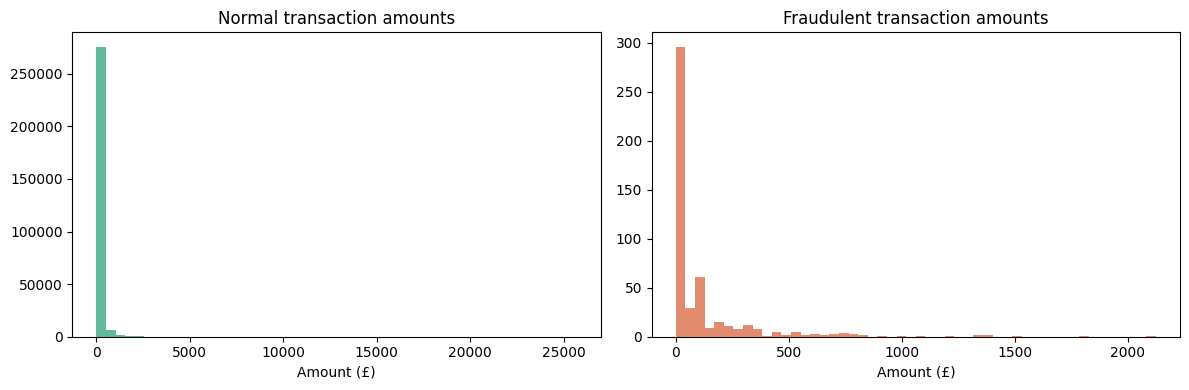

In [3]:
# Transaction amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='#1D9E75', alpha=0.7)
axes[0].set_title('Normal transaction amounts')
axes[0].set_xlabel('Amount (£)')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#D85A30', alpha=0.7)
axes[1].set_title('Fraudulent transaction amounts')
axes[1].set_xlabel('Amount (£)')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

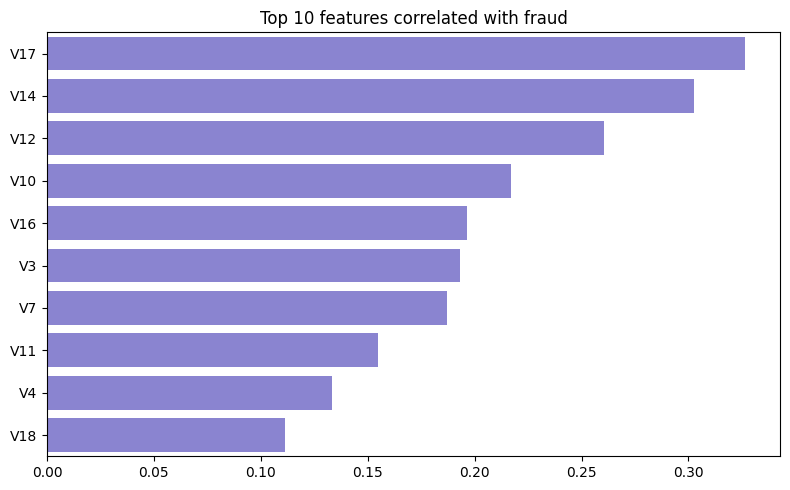

Top features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


In [4]:
# Correlation heatmap of top features
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = corr.head(10).index.tolist()

plt.figure(figsize=(8, 5))
sns.barplot(x=corr.head(10).values, y=top_features, color='#7F77DD')
plt.title('Top 10 features correlated with fraud')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top features:", top_features)

In [5]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df_model = df.drop(['Time', 'Amount', 'Class'], axis=1)

# Store true labels separately (for evaluation only — Isolation Forest is unsupervised)
y_true = df['Class'].values

print("Features for model:", df_model.shape)
print("Sample of scaled data:")
print(df_model[['Amount_scaled', 'Time_scaled']].head())

Features for model: (284807, 30)
Sample of scaled data:
   Amount_scaled  Time_scaled
0       0.244964    -1.996583
1      -0.342475    -1.996583
2       1.160686    -1.996562
3       0.140534    -1.996562
4      -0.073403    -1.996541


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Train model
# contamination = expected % of anomalies in the data
# 0.002 = roughly 0.2%, close to the real fraud rate
model = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

print("Training model...")
model.fit(df_model)
print("Done!")

# Predict: -1 = anomaly, 1 = normal
# Convert to 0/1 to match our labels
preds_raw = model.predict(df_model)
preds = [1 if x == -1 else 0 for x in preds_raw]

# Anomaly scores (lower = more anomalous)
scores = model.score_samples(df_model)
df['anomaly_score'] = scores
df['predicted_anomaly'] = preds

print("\nPrediction summary:")
print(pd.Series(preds).value_counts())

Training model...
Done!

Prediction summary:
0    284237
1       570
Name: count, dtype: int64


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
     Anomaly       0.26      0.30      0.28       492

    accuracy                           1.00    284807
   macro avg       0.63      0.65      0.64    284807
weighted avg       1.00      1.00      1.00    284807



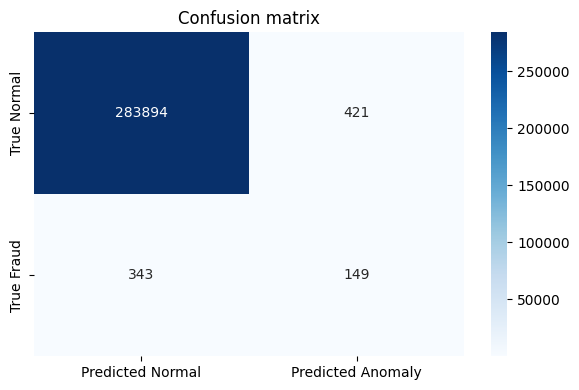


Frauds caught: 149 / 492 (30.3%)


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report:")
print(classification_report(y_true, preds, target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['True Normal', 'True Fraud'])
plt.title('Confusion matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# How many real frauds did we catch?
fraud_caught = df[(df['Class']==1) & (df['predicted_anomaly']==1)].shape[0]
total_fraud = df['Class'].sum()
print(f"\nFrauds caught: {fraud_caught} / {total_fraud} ({round(fraud_caught/total_fraud*100, 1)}%)")

# New section

In [8]:
# Create clean export file
export_df = df[['Time', 'Amount', 'Class', 'predicted_anomaly', 'anomaly_score']].copy()

# Rename for Power BI readability
export_df.columns = ['Time', 'Amount', 'True_Fraud', 'Predicted_Anomaly', 'Anomaly_Score']

# Add human-readable labels
export_df['Transaction_Type'] = export_df['True_Fraud'].map({0: 'Normal', 1: 'Fraud'})
export_df['Flag'] = export_df['Predicted_Anomaly'].map({0: 'Normal', 1: 'Flagged'})

# Add a time-based column (convert seconds to hours)
export_df['Hour'] = (export_df['Time'] // 3600 % 24).astype(int)

export_df.to_csv('/content/drive/MyDrive/gl_anomaly_project/scored_transactions.csv', index=False)
print("Exported!", export_df.shape)
print(export_df.head())

Exported! (284807, 8)
   Time  Amount  True_Fraud  Predicted_Anomaly  Anomaly_Score  \
0   0.0  149.62           0                  0      -0.382906   
1   0.0    2.69           0                  0      -0.362553   
2   1.0  378.66           0                  0      -0.458869   
3   1.0  123.50           0                  0      -0.406332   
4   2.0   69.99           0                  0      -0.383507   

  Transaction_Type    Flag  Hour  
0           Normal  Normal     0  
1           Normal  Normal     0  
2           Normal  Normal     0  
3           Normal  Normal     0  
4           Normal  Normal     0  


In [1]:
import os
files = os.listdir('/content')
print(files)

['.config', 'sample_data']


In [2]:
import os
project_dir = '/content/drive/MyDrive/gl_anomaly_project/'
if os.path.exists(project_dir):
    project_files = os.listdir(project_dir)
    print(f"Files in {project_dir}:\n{project_files}")
else:
    print(f"Directory {project_dir} does not exist.")

Directory /content/drive/MyDrive/gl_anomaly_project/ does not exist.
